<a href="https://colab.research.google.com/github/ARNAVKS/Nifty50-forecasting/blob/main/NIFTY50_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIFTY50 Stock Price Forecasting
**Pipeline:** EDA → Stationarity → LSTM → GRU → Model Comparison → Forecast

In [1]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=8c77a5834fa9c5b20cbe470374818588e58ef74ef442da598d662e5f6f2710c1
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


## Phase 1: Imports & Data Collection

In [8]:
# Install dependencies if needed
# !pip install yfinance ta statsmodels keras tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import ta

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.style.use('seaborn-v0_8-darkgrid')
print('All imports successful')
print(f'TensorFlow version: {tf.__version__}')

All imports successful
TensorFlow version: 2.20.0


In [9]:
# Download NIFTY50 data — 10 years
ticker = '^NSEI'
df = yf.download(ticker, start='2014-01-01', end='2024-12-31', auto_adjust=True)
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2698, 5)
Date range: 2014-01-02 to 2024-12-30


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


## Phase 2: EDA

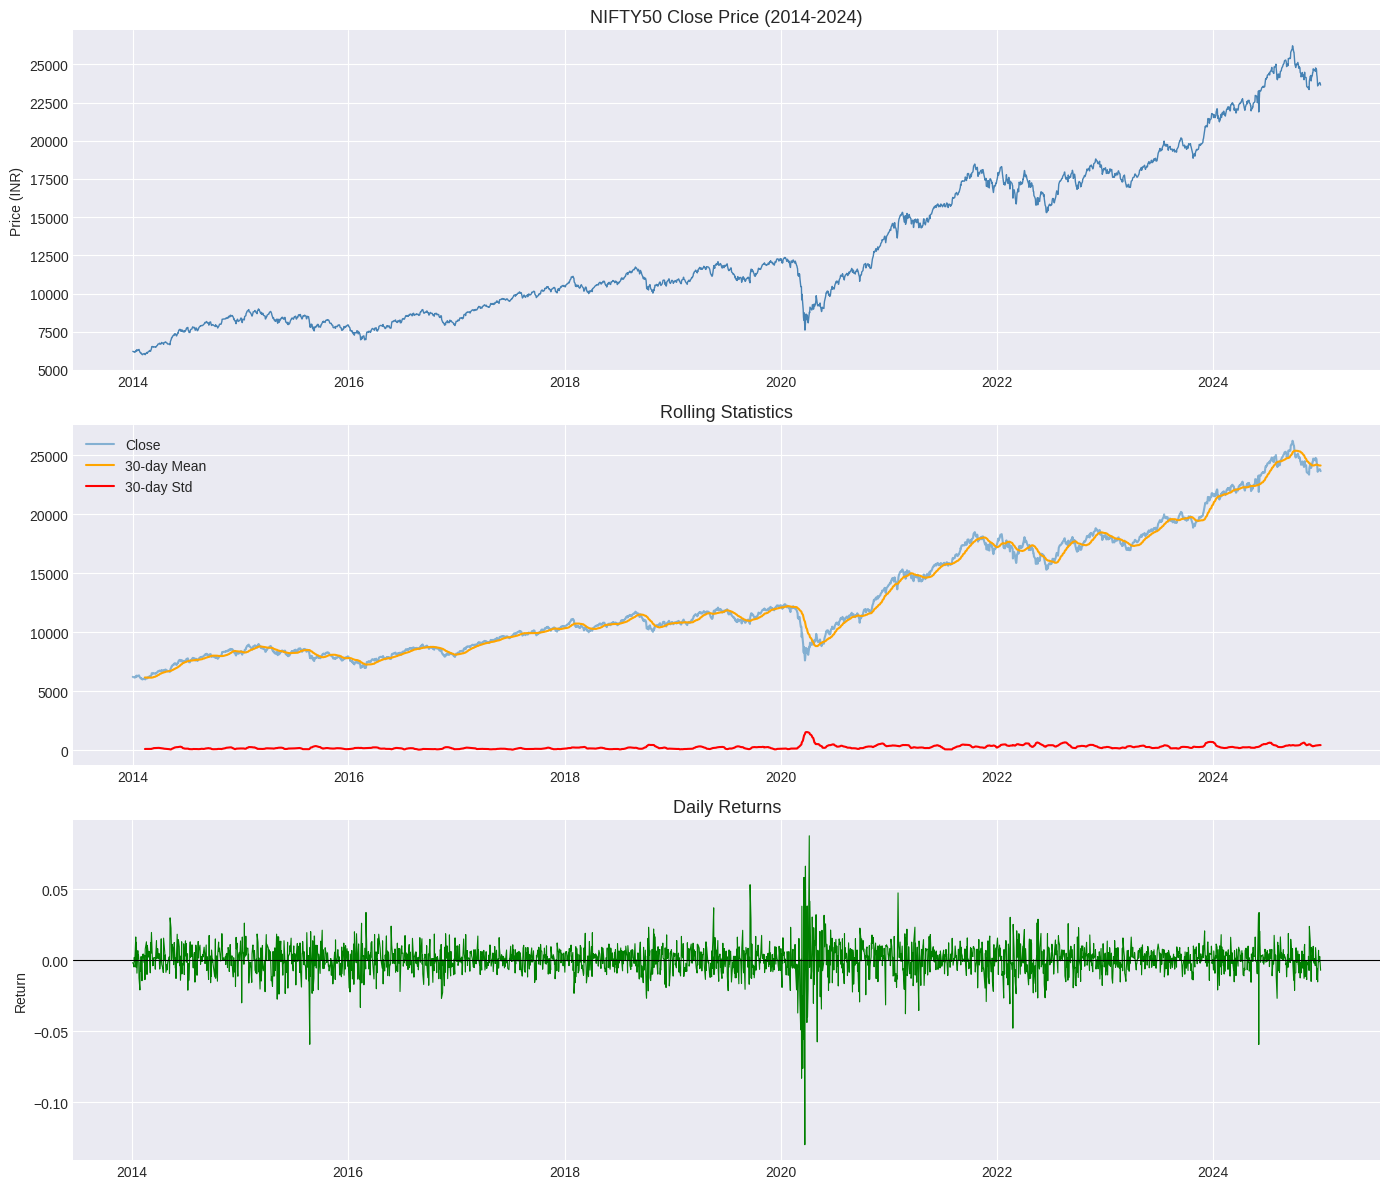

Ticker         ^NSEI
count    2698.000000
mean    12957.142406
std      5055.254735
min      6000.899902
25%      8639.187500
50%     11085.075195
75%     17275.800781
max     26216.050781


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Close price
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('NIFTY50 Close Price (2014-2024)', fontsize=13)
axes[0].set_ylabel('Price (INR)')

# Rolling mean & std
roll = df['Close'].rolling(window=30)
axes[1].plot(df.index, df['Close'], label='Close', alpha=0.5)
axes[1].plot(df.index, roll.mean(), label='30-day Mean', color='orange')
axes[1].plot(df.index, roll.std(), label='30-day Std', color='red')
axes[1].set_title('Rolling Statistics', fontsize=13)
axes[1].legend()

# Daily returns
df['Returns'] = df['Close'].pct_change()
axes[2].plot(df.index, df['Returns'], color='green', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Daily Returns', fontsize=13)
axes[2].set_ylabel('Return')

plt.tight_layout()
plt.show()

print(df['Close'].describe())

## Phase 3: Stationarity Tests

In [11]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {name} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Stationary    : {"Yes" if result[1] < 0.05 else "No"}\n')

def kpss_test(series, name='Series'):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'--- KPSS Test: {name} ---')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Stationary    : {"Yes" if result[1] > 0.05 else "No"}\n')

close = df['Close']
adf_test(close, 'Close Price')
kpss_test(close, 'Close Price')

# First differencing
close_diff = close.diff().dropna()
adf_test(close_diff, 'Close Price (1st Diff)')
kpss_test(close_diff, 'Close Price (1st Diff)')

--- ADF Test: Close Price ---
ADF Statistic : 0.3315
p-value       : 0.9787
Stationary    : No

--- KPSS Test: Close Price ---
KPSS Statistic: 7.5869
p-value       : 0.0100
Stationary    : No



/tmp/ipykernel_5068/2415115641.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


--- ADF Test: Close Price (1st Diff) ---
ADF Statistic : -21.4484
p-value       : 0.0000
Stationary    : Yes

--- KPSS Test: Close Price (1st Diff) ---
KPSS Statistic: 0.1526
p-value       : 0.1000
Stationary    : Yes



/tmp/ipykernel_5068/2415115641.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


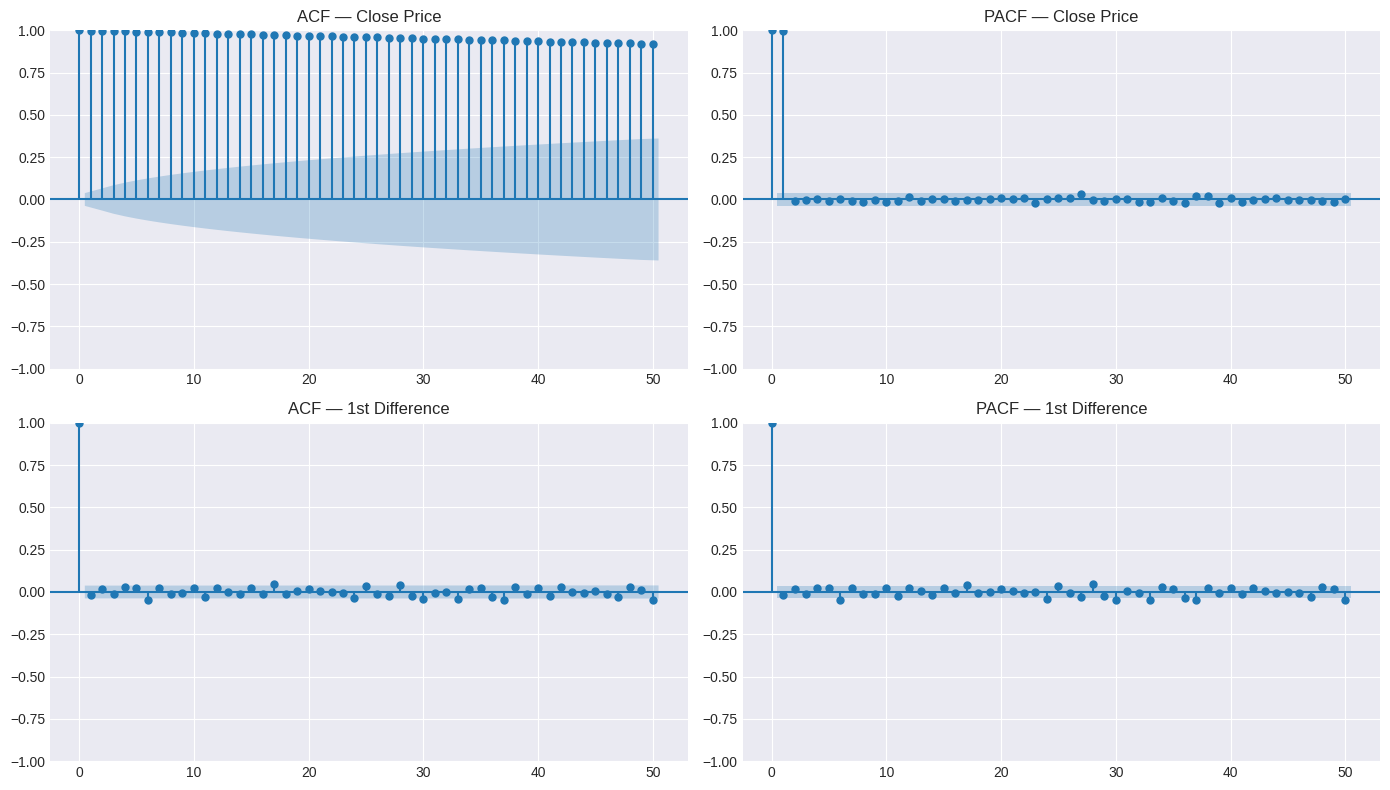

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(close, lags=50, ax=axes[0, 0], title='ACF — Close Price')
plot_pacf(close, lags=50, ax=axes[0, 1], title='PACF — Close Price')
plot_acf(close_diff, lags=50, ax=axes[1, 0], title='ACF — 1st Difference')
plot_pacf(close_diff, lags=50, ax=axes[1, 1], title='PACF — 1st Difference')

plt.tight_layout()
plt.show()

## Phase 4: Feature Engineering

In [13]:
data = df[['Close', 'Volume']].copy()

# Lag features
for lag in [1, 2, 3, 5, 7, 14]:
    data[f'lag_{lag}'] = data['Close'].shift(lag)

# Rolling stats
data['rolling_mean_7']  = data['Close'].rolling(7).mean()
data['rolling_mean_30'] = data['Close'].rolling(30).mean()
data['rolling_std_7']   = data['Close'].rolling(7).std()

# Technical indicators
close_series = data['Close'].squeeze()
data['RSI']    = ta.momentum.RSIIndicator(close_series, window=14).rsi()
data['MACD']   = ta.trend.MACD(close_series).macd()
data['BB_high'] = ta.volatility.BollingerBands(close_series).bollinger_hband()
data['BB_low']  = ta.volatility.BollingerBands(close_series).bollinger_lband()

data.dropna(inplace=True)
print(f'Feature matrix shape: {data.shape}')
data.head()

Feature matrix shape: (2669, 15)


Price,Close,Volume,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,rolling_mean_7,rolling_mean_30,rolling_std_7,RSI,MACD,BB_high,BB_low
Ticker,^NSEI,^NSEI,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2014-02-12,6084.000000,138500,6062.700195,6053.450195,6063.200195,6022.399902,6001.799805,6345.649902,6046.135742,6171.861686,28.163797,42.178463,-48.616622,6392.858576,5909.136443
2014-02-13,6001.100098,153700,6084.000000,6062.700195,6053.450195,6036.299805,6000.899902,6266.750000,6046.164342,6164.526693,28.110257,33.772697,-51.717893,6372.473087,5897.741953
2014-02-14,6048.350098,140200,6001.100098,6084.000000,6062.700195,6063.200195,6022.399902,6135.850098,6049.871512,6159.100033,26.092612,40.991032,-49.789055,6357.230457,5891.654601
2014-02-18,6127.100098,126600,6048.350098,6001.100098,6084.000000,6053.450195,6036.299805,6126.250000,6062.842983,6156.955029,38.050835,50.646092,-41.428409,6333.394129,5897.805920
2014-02-19,6152.750000,95200,6127.100098,6048.350098,6001.100098,6062.700195,6063.200195,6120.250000,6075.635812,6156.638363,51.030620,53.324903,-32.359780,6306.530687,5908.564381


## Phase 5: Train/Val/Test Split

In [14]:
# 70/15/15 split — no shuffle (time order matters)
n = len(data)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = data.iloc[:train_end]
val   = data.iloc[train_end:val_end]
test  = data.iloc[val_end:]

print(f'Train : {train.shape} | {train.index[0].date()} to {train.index[-1].date()}')
print(f'Val   : {val.shape}   | {val.index[0].date()} to {val.index[-1].date()}')
print(f'Test  : {test.shape}  | {test.index[0].date()} to {test.index[-1].date()}')

Train : (1868, 15) | 2014-02-12 to 2021-09-30
Val   : (400, 15)   | 2021-10-01 to 2023-05-15
Test  : (401, 15)  | 2023-05-16 to 2024-12-30


## Phase 6: Deep Learning — LSTM & GRU

In [15]:
# Scale Close price
scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(data[['Close']])

# Sequence windowing
LOOKBACK = 60

def create_sequences(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(close_scaled, LOOKBACK)

# Split indices aligned to data (after dropna)
n2 = len(X_all)
t1 = int(n2 * 0.70)
t2 = int(n2 * 0.85)

X_train, y_train = X_all[:t1], y_all[:t1]
X_val,   y_val   = X_all[t1:t2], y_all[t1:t2]
X_test,  y_test  = X_all[t2:], y_all[t2:]

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape(-1, LOOKBACK, 1)
X_val   = X_val.reshape(-1, LOOKBACK, 1)
X_test  = X_test.reshape(-1, LOOKBACK, 1)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (1826, 60, 1) | X_val: (391, 60, 1) | X_test: (392, 60, 1)


In [16]:
def build_lstm():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - loss: 0.0044 - val_loss: 5.2269e-04 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 6.0162e-04 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 5.5305e-04 - val_loss: 3.8818e-04 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 4.4479e-04 - val_loss: 6.5532e-04 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 4.4411e-04 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 4.6850e-04 - val_loss: 9.2733e-04 - learning_rate: 0.0010
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 3.3285e-04 - val_loss: 3.7321e-04 - learning_rate: 0.0010
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - loss: 3.1622e-04 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 9/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - loss: 3

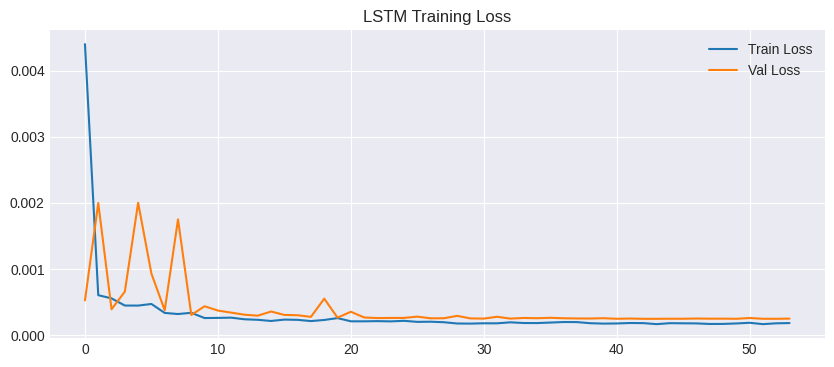

In [17]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.show()

In [18]:
def build_gru():
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

gru_model = build_gru()

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - loss: 0.0051 - val_loss: 3.4026e-04 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 5.5418e-04 - val_loss: 2.1365e-04 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 4.2433e-04 - val_loss: 2.0912e-04 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 4.0531e-04 - val_loss: 2.6397e-04 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 3.4273e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 2.9320e-04 - val_loss: 2.8950e-04 - learning_rate: 5.0000e-04
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 3.1354e-04 - val_loss: 2.1201e-04 - learning_rate: 5.0000e-04
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 2.9969e-04 - val_loss: 1.6093e-04 - learning_rate: 5.0000e-04
Epoch 9/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 11

In [20]:
# Evaluate LSTM
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_mae  = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
print(f'LSTM — MAE: {lstm_mae:.2f} | RMSE: {lstm_rmse:.2f}')

# Evaluate GRU
gru_pred_scaled = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_mae  = mean_absolute_error(y_test_actual, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_pred))
print(f'GRU  — MAE: {gru_mae:.2f} | RMSE: {gru_rmse:.2f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
LSTM — MAE: 247.89 | RMSE: 317.02
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
GRU  — MAE: 220.80 | RMSE: 275.42


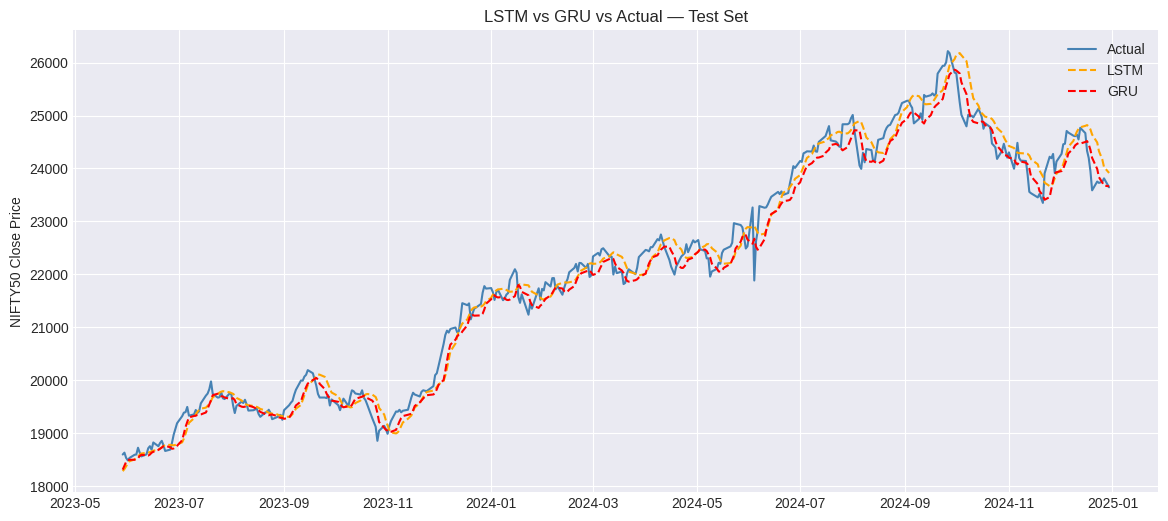

In [21]:
# Plot LSTM & GRU predictions
test_dates = data.index[LOOKBACK + t2:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual', color='steelblue', linewidth=1.5)
plt.plot(test_dates, lstm_pred, label='LSTM', color='orange', linestyle='--')
plt.plot(test_dates, gru_pred, label='GRU', color='red', linestyle='--')
plt.title('LSTM vs GRU vs Actual — Test Set')
plt.ylabel('NIFTY50 Close Price')
plt.legend()
plt.show()

## Phase 7: Model Comparison — LSTM vs GRU

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Model        MAE       RMSE
  GRU 220.803547 275.423818
 LSTM 247.890012 317.022207


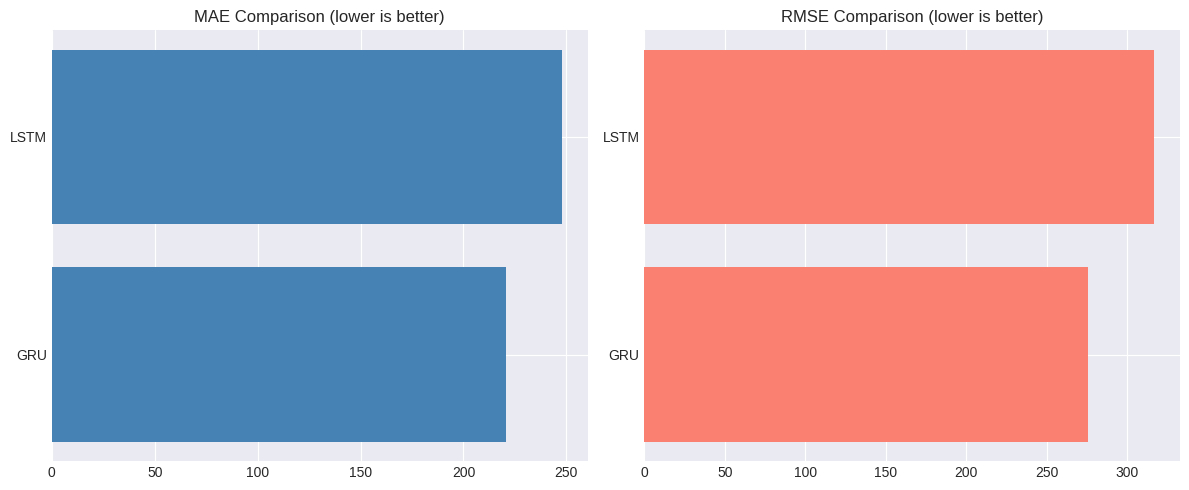

In [22]:
# Evaluate LSTM
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_mae  = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

# Evaluate GRU
gru_pred_scaled = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred_scaled)

gru_mae  = mean_absolute_error(y_test_actual, gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_pred))

results = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'MAE':   [lstm_mae, gru_mae],
    'RMSE':  [lstm_rmse, gru_rmse]
})
results = results.sort_values('MAE').reset_index(drop=True)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(results['Model'], results['MAE'], color='steelblue')
axes[0].set_title('MAE Comparison (lower is better)')
axes[1].barh(results['Model'], results['RMSE'], color='salmon')
axes[1].set_title('RMSE Comparison (lower is better)')
plt.tight_layout()
plt.show()

## Phase 8: Future Forecast (Next 30 Days)

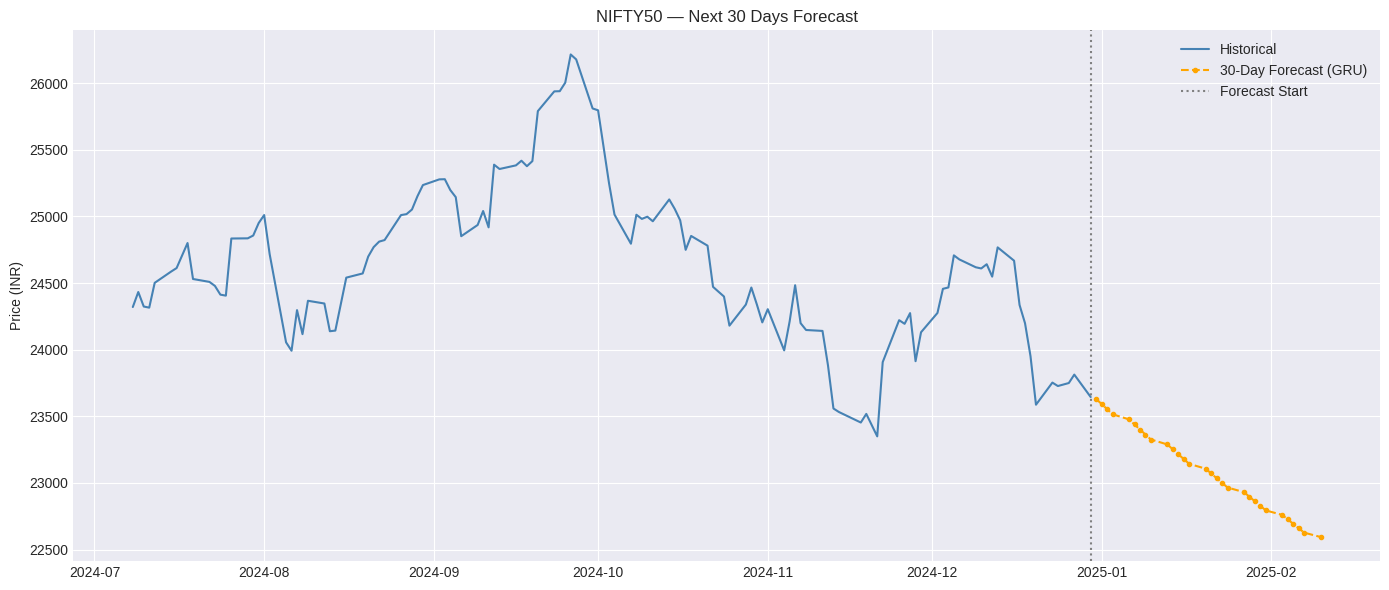

Last known price : ₹Ticker             ^NSEI
Date                    
2014-02-12   6084.000000
2014-02-13   6001.100098
2014-02-14   6048.350098
2014-02-18   6127.100098
2014-02-19   6152.750000
...                  ...
2024-12-23  23753.449219
2024-12-24  23727.650391
2024-12-26  23750.199219
2024-12-27  23813.400391
2024-12-30  23644.900391

[2669 rows x 1 columns]
Forecast (Day 30): ₹22,594.61


In [23]:
# Use best DL model (GRU) to forecast next 30 days iteratively
FORECAST_DAYS = 30
last_sequence = close_scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)

future_preds = []
seq = last_sequence.copy()

for _ in range(FORECAST_DAYS):
    pred = gru_model.predict(seq, verbose=0)[0, 0]
    future_preds.append(pred)
    seq = np.roll(seq, -1, axis=1)
    seq[0, -1, 0] = pred

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

last_date    = data.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

plt.figure(figsize=(14, 6))
plt.plot(data.index[-120:], data['Close'].values[-120:], label='Historical', color='steelblue')
plt.plot(future_dates, future_preds, label='30-Day Forecast (GRU)', color='orange', linestyle='--', marker='o', markersize=3)
plt.axvline(x=last_date, color='gray', linestyle=':', label='Forecast Start')
plt.title('NIFTY50 — Next 30 Days Forecast')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Forecast (Day 30): ₹{future_preds[-1][0]:,.2f}')